# NHL Trap Games

Definition: A trap game is about a good team underperforming when they're expected to win

In [34]:
import sys
import os
import polars as pl
from tqdm import tqdm
from typing import List
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import optuna
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

base_dir = '../'
sys.path.insert(1, base_dir)

import src.config as cfg
import src.utils as utils
import src.sportsipy_utils as sportsipy_utils

## Pull Schedule for Each NHL Team

Note: We are using *All Situations* as a trap game is more about the actual results on the ice than it is about a team's true underlying ability

In [2]:
# Warning: NHL Schedules not loading - https://github.com/davidjkrause/sportsipy/issues/14
# sportsipy_utils.pull_nhl_schedule('TOR', 2024)

In [3]:
# https://www.naturalstattrick.com/games.php?fromseason=20242025&thruseason=20242025&stype=2&sit=all&loc=B&team=All&rate=n
schedule_folder = f'{base_dir}data/natural_stat_trick'

df_games = []
for filename in tqdm(os.listdir(schedule_folder)):
    if 'games_' in filename:
        schedule_filepath = os.path.join(schedule_folder, filename)
        df_games_filepath = pl.scan_csv(schedule_filepath, null_values=["-"]).collect()
        if not df_games_filepath.is_empty():
            df_games += [df_games_filepath]
    
df_games = (pl.concat(df_games)
            .unique(subset=['Game', 'Team'], keep='first')
            .with_columns(
                pl.col('Game').str.split(" - ").list.get(0).str.strip_chars().str.strptime(pl.Datetime,'%Y-%m-%d').alias('Date')
            )
            .select(['Game', 'Team', 'Date', 'GF', 'GA', 'GF%', 'xGF', 'xGA', 'xGF%', 'SH%', 'SV%' ,'PDO'])
           )
utils.logger.info(f"Loaded {df_games.shape[0]/2} unique games from natural stattrick") 
df_games.head(5)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 104.98it/s]
2025-09-14 01:12:34,971 [4006499702.py:19] [INFO] Loaded 21528.0 unique games from natural stattrick


Game,Team,Date,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64
""" 2015-12-21 - Blues 3, Flyers …","""St Louis Blues""",2015-12-21 00:00:00,3,4,42.86,2.09,3.4,38.14,10.34,87.1,0.974
""" 2011-12-29 - Flyers 4, Pengui…","""Pittsburgh Penguins""",2011-12-29 00:00:00,2,4,33.33,1.88,2.52,42.75,7.69,82.61,0.903
""" 2021-10-16 - Stars 1, Bruins …","""Boston Bruins""",2021-10-16 00:00:00,3,1,75.0,3.06,2.4,56.01,7.5,96.43,1.039
""" 2013-04-13 - Flames 4, Oilers…","""Edmonton Oilers""",2013-04-13 00:00:00,1,4,20.0,3.04,4.07,42.7,3.45,89.47,0.929
""" 2011-12-30 - Sabres 1, Capita…","""Washington Capitals""",2011-12-30 00:00:00,3,1,75.0,1.44,3.04,32.1,14.29,96.15,1.104


In [4]:
df_missing = df_games.filter(pl.col("GF%").is_null())
utils.logger.info(f"Found {df_missing.shape[0]} / {df_games.shape[0]} rows without any goals in all situations")

2025-09-14 01:12:34,989 [659697710.py:2] [INFO] Found 104 / 43056 rows without any goals in all situations


## Identify Trap Games

In [5]:
strength_col = "Points"
strong_threshold = 1.05
weak_threshold = 0.95

df_games_processed = (
    df_games.filter(pl.col("GF%").is_not_null())
      .unique(subset=['Game', 'Team'], keep='first')

        # Derive # Points a team earns in a game
      .sort("Game", descending=False)
      .with_columns([
        pl.when(pl.col("Date").dt.month() >= 7).then(pl.col("Date").dt.year() + 1)
            .otherwise(pl.col("Date").dt.year())
            .alias("Season"),
          pl.when(pl.col("GF%")>50).then(pl.lit(2))
              .when(pl.col("GF%")<50).then(pl.lit(0))
              .otherwise(pl.lit(1))
          .alias("Points")
      ])

    # Derive rolling average # points the team has earned so far
    .with_columns([
        pl.col(strength_col).cum_sum().over(["Team", "Season"]).alias("Season to Date Total incl Current"),
        pl.col("GF%").cum_count().over(["Team", "Season"]).alias("# Games Season to Date incl Current")
    ])
    .with_columns(
        ((pl.col("Season to Date Total incl Current") - pl.col(strength_col))/
         (pl.col("# Games Season to Date incl Current") - 1)).alias(f"Season to Date Average {strength_col}")
    )
    .with_columns([
        ((pl.col(f"Season to Date Average {strength_col}") > strong_threshold) 
         & (pl.col("# Games Season to Date incl Current") > 20)).alias("is_strong"),
        ((pl.col(f"Season to Date Average {strength_col}") < weak_threshold) 
         & (pl.col("# Games Season to Date incl Current") > 20)).alias("is_weak"),

        pl.when(pl.col("Season") <= 2012).then(pl.lit("Pre-Lockout (2007–2012)"))
            .when((pl.col("Season") >= 2013) & (pl.col("Season") <= 2019)).then(pl.lit("Post-Lockout (2013-2019)"))
            .when((pl.col("Season") >= 2020) & (pl.col("Season") <= 2021)).then(pl.lit("Pandemic (2020–2021)"))
            .otherwise(pl.lit("Post-Pandemic (2022–2025)"))
            .alias("Season Bucket")
    ])

    # # Days since last game
    .sort(["Team", "Season", "Date"])
    .with_columns(
        (pl.col("Date").diff().dt.total_days()).over(["Team", "Season"]).fill_null(0).alias("# Days since Last Game")
    )

    # Check if Home Team
    .with_columns(
        pl.col("Game").str.split(",").list.get(-1).str.strip_chars().str.replace(r"\s+\d+$", "")
            .str.split(" ").list.get(-1).str.strip_chars() # needed for edge cases like "Maple Leafs"
            .alias("home_team_name")
    )
    .with_columns(
        (pl.col("Team").str.split(" ").list.get(-1).str.strip_chars() == pl.col("home_team_name")).alias("is_home_team")
    )
)  
                     
display(df_games_processed.tail(5))
df_games_processed.mean()

Game,Team,Date,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO,Season,Points,Season to Date Total incl Current,# Games Season to Date incl Current,Season to Date Average Points,is_strong,is_weak,Season Bucket,# Days since Last Game,home_team_name,is_home_team
str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,u32,f64,bool,bool,str,i64,str,bool
""" 2025-04-07 - Blues 1, Jets 3""","""Winnipeg Jets""",2025-04-07 00:00:00,3,1,75.0,4.35,1.33,76.59,11.54,93.33,1.049,2025,2,106,78,1.350649,true,false,"""Post-Pandemic (2022–2025)""",2,"""Jets""",true
""" 2025-04-10 - Jets 4, Stars 0""","""Winnipeg Jets""",2025-04-10 00:00:00,4,0,100.0,3.01,2.78,52.04,11.43,100.0,1.114,2025,2,108,79,1.358974,true,false,"""Post-Pandemic (2022–2025)""",3,"""Stars""",false
""" 2025-04-12 - Jets 5, Blackhaw…","""Winnipeg Jets""",2025-04-12 00:00:00,4,4,50.0,3.96,3.28,54.74,9.52,87.5,0.97,2025,1,109,80,1.367089,true,false,"""Post-Pandemic (2022–2025)""",2,"""Blackhawks""",false
""" 2025-04-13 - Oilers 4, Jets 1""","""Winnipeg Jets""",2025-04-13 00:00:00,1,4,20.0,2.36,4.73,33.25,5.56,89.74,0.953,2025,0,109,81,1.3625,true,false,"""Post-Pandemic (2022–2025)""",1,"""Jets""",true
""" 2025-04-16 - Ducks 1, Jets 2""","""Winnipeg Jets""",2025-04-16 00:00:00,2,1,66.67,3.89,2.78,58.29,4.55,96.77,1.013,2025,2,111,82,1.345679,true,false,"""Post-Pandemic (2022–2025)""",3,"""Jets""",true


Game,Team,Date,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO,Season,Points,Season to Date Total incl Current,# Games Season to Date incl Current,Season to Date Average Points,is_strong,is_weak,Season Bucket,# Days since Last Game,home_team_name,is_home_team
str,str,datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64
null,null,2016-08-21 05:52:29.413298,2.860286,2.860239,50.000698,2.768069,2.768026,50.000408,9.730112,90.27024,1.000004,2016.603511,1.000023,40.025028,40.005751,NaN,0.300661,0.29689,null,2.258801,null,0.499045


In [6]:
# Double check season derivation is reasonable given lockout in the 2012-2013 season and pandemic in 2019-2020/2020-2021 seasons
df_games_processed.group_by("Season").agg(pl.col("Game").count()).sort("Game").head(5)

Season,Game
i32,u32
2013,1434
2021,1730
2020,2160
2010,2448
2015,2448


In [7]:
df_opponent = df_games_processed.select(
    [pl.col("Game"),
     pl.col("Team").alias("Opponent"),
    ] + [pl.col(col).alias(f"Opponent {col}") 
         for col in [f"Season to Date Average {strength_col}", "is_strong", "is_weak", "# Days since Last Game"]]
)

df_games_with_opponent = (
    df_games_processed.join(df_opponent, on="Game", how="left")
    .filter(pl.col("Team") != pl.col("Opponent"))
    .with_columns(
        (pl.col(f"Season to Date Average {strength_col}") - pl.col(f"Opponent Season to Date Average {strength_col}")).alias(f"Delta {strength_col}")
    )

    # Tag previous opponent
    .sort(["Team", "Date"])
    .with_columns([
        pl.col(col).shift(1).over(["Team", "Season"]).alias(f"Previous {col}")
        for col in ["Opponent", "Opponent is_strong", "Opponent is_weak", "GF%"]
    ])

    # Tag Trap Games: Strong Team that beat another strong team in the previous game faces a weak opponent in the next game
    .with_columns(
        pl.when((pl.col("is_strong"))&(pl.col("Opponent is_weak"))
                &(pl.col("Previous Opponent is_strong"))&(pl.col("Previous GF%") > 50))
            .then(pl.lit(True))
        .otherwise(pl.lit(False)).alias("Trap Game")
    )

    # Identify games where opponent is more rested
    .with_columns(
        pl.when(pl.col("# Days since Last Game") < pl.col("Opponent # Days since Last Game")).then(pl.lit("Fatigued Team"))
        .when(pl.col("# Days since Last Game") == pl.col("Opponent # Days since Last Game")).then(pl.lit("Equal Fatigue"))
            .otherwise(pl.lit("Fatigued Opponent")).alias("Fatigue Level")
    )
    .with_columns(
        (pl.when((pl.col("# Days since Last Game") > 1)
                &(pl.col("Opponent # Days since Last Game") > 1) # if neither team is playing on a back-to-back, then disregard fatigue
               ).then(pl.lit(None))
            .otherwise(pl.col("Fatigue Level"))
        ).alias("Fatigue Level")
    )
)

assert df_games_with_opponent.shape[0] == df_games_processed.shape[0]

num_trap_games = df_games_with_opponent.filter(pl.col("Trap Game")).shape[0]
num_games = df_games_with_opponent.shape[0]
utils.logger.info(f"Trap games comprise {np.round(100*num_trap_games/num_games, 1)}% ({num_trap_games}/{num_games})")

2025-09-14 01:12:35,125 [3571687730.py:49] [INFO] Trap games comprise 2.3% (1000/42952)


In [8]:
df_leafs_sample = df_games_with_opponent.filter((pl.col("Team")=="Toronto Maple Leafs")&(pl.col("Season")==2025))
display(df_leafs_sample.head(5))

df_leafs_sample.write_csv(f"{base_dir}data/derived/Leafs Trap Games Sample.csv")

Game,Team,Date,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO,Season,Points,Season to Date Total incl Current,# Games Season to Date incl Current,Season to Date Average Points,is_strong,is_weak,Season Bucket,# Days since Last Game,home_team_name,is_home_team,Opponent,Opponent Season to Date Average Points,Opponent is_strong,Opponent is_weak,Opponent # Days since Last Game,Delta Points,Previous Opponent,Previous Opponent is_strong,Previous Opponent is_weak,Previous GF%,Trap Game,Fatigue Level
str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,u32,f64,bool,bool,str,i64,str,bool,str,f64,bool,bool,i64,f64,str,bool,bool,f64,bool,str
""" 2024-10-09 - Maple Leafs 0, C…","""Toronto Maple Leafs""",2024-10-09 00:00:00,0,1,0.0,6.09,2.97,67.2,0.0,96.3,0.963,2025,0,0,1,NaN,false,false,"""Post-Pandemic (2022–2025)""",0,"""Canadiens""",false,"""Montreal Canadiens""",NaN,false,false,0,NaN,null,null,null,null,false,"""Equal Fatigue"""
""" 2024-10-10 - Maple Leafs 4, D…","""Toronto Maple Leafs""",2024-10-10 00:00:00,4,2,66.67,2.11,2.62,44.67,18.18,91.3,1.095,2025,2,2,2,0.0,false,false,"""Post-Pandemic (2022–2025)""",1,"""Devils""",false,"""New Jersey Devils""",2.0,false,false,5,-2.0,"""Montreal Canadiens""",false,false,0.0,false,"""Fatigued Team"""
""" 2024-10-12 - Penguins 2, Mapl…","""Toronto Maple Leafs""",2024-10-12 00:00:00,4,2,66.67,2.95,1.89,60.94,12.12,91.3,1.034,2025,2,4,3,1.0,false,false,"""Post-Pandemic (2022–2025)""",2,"""Leafs""",true,"""Pittsburgh Penguins""",1.0,false,false,2,0.0,"""New Jersey Devils""",false,false,66.67,false,null
""" 2024-10-16 - Kings 2, Maple L…","""Toronto Maple Leafs""",2024-10-16 00:00:00,6,2,75.0,1.86,4.75,28.12,23.08,94.12,1.172,2025,2,6,4,1.333333,false,false,"""Post-Pandemic (2022–2025)""",4,"""Leafs""",true,"""Los Angeles Kings""",0.666667,false,false,2,0.666667,"""Pittsburgh Penguins""",false,false,66.67,false,null
""" 2024-10-19 - Rangers 4, Maple…","""Toronto Maple Leafs""",2024-10-19 00:00:00,1,4,20.0,3.98,5.07,44.0,2.86,86.21,0.891,2025,0,6,5,1.5,false,false,"""Post-Pandemic (2022–2025)""",3,"""Leafs""",true,"""New York Rangers""",1.5,false,false,2,0.0,"""Los Angeles Kings""",false,false,75.0,false,null


## Aggregate Tables

In [9]:
def get_agg_tables(df: pl.DataFrame, groupby_cols: List[str]) -> [pl.DataFrame, pl.DataFrame]:
    """
    Group schedule list to compare team performance in trap games
    :param df: pl.DataFrame
    :param groupby_cols: list
    :return: [pl.DataFrame, pl.DataFrame]
    """
    df_agg = (
        df.filter((pl.col("is_strong"))&(pl.col("Opponent is_weak")) # compare strong vs weak games
                 )
            .drop_nulls(subset=groupby_cols)
        .group_by(groupby_cols + ['Trap Game']) # depending on whether the strong team won against another strong team the previous game
        .agg([pl.col('Game').count().alias('Sample Size').cast(pl.Int32)] 
             + [pl.col(col).mean() for col in ['GF', 'GA', 'GF%', 'xGF', 'xGA', 'xGF%', 'SH%', 'SV%', 'PDO']])
        .sort(groupby_cols + ['Trap Game'])
    )

    # Calculate % change
    value_cols = [col for col in df_agg.columns if col not in groupby_cols and col != 'Trap Game']
    if len(groupby_cols) == 0:
        df_pct_change = df_agg.filter(pl.col('Trap Game')).select(value_cols) / df_agg.filter(~pl.col('Trap Game')).select(value_cols) - 1
    else:
        df_pct_change = (df_agg
            .pivot(index=groupby_cols, on='Trap Game', values=value_cols)
            .with_columns([(pl.col(f'{col}_true') / pl.col(f'{col}_false') - 1).alias(col) 
                           for col in value_cols])
            .drop([f'{col}_true' for col in value_cols] + [f'{col}_false' for col in value_cols])
        )
    
    return df_agg, df_pct_change

In [10]:
writer = pd.ExcelWriter(f'{base_dir}data/derived/Trap Games Pivot Tables.xlsx')

for groupby_cols in [[], ['is_home_team'], ['Fatigue Level'], 
                     ['Season Bucket'], ['Season'], ['Team'],
                     ['Season Bucket', 'Team'], ['Season', 'Team']]:
    df_agg, df_pct_change = get_agg_tables(df_games_with_opponent, groupby_cols)

    utils.logger.info(f"Pivot tables by {groupby_cols}")
    display(df_agg)
    display(df_pct_change)

    df_agg.to_pandas().to_excel(writer, sheet_name=f"Agg {'_'.join(groupby_cols)}", index=False)
    df_pct_change.to_pandas().to_excel(writer, sheet_name=f"% Change {'_'.join(groupby_cols)}", index=False)

writer.close()

2025-09-14 01:12:35,390 [3600981367.py:8] [INFO] Pivot tables by []


Trap Game,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
bool,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64
false,4330,3.216166,2.582448,55.835048,2.969596,2.599381,53.298988,10.365947,90.757222,1.011229
true,1000,3.304,2.577,56.98759,3.01415,2.5897,53.72286,10.70956,90.84669,1.015555


Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.769053,0.02731,-0.00211,0.020642,0.015003,-0.003724,0.007953,0.033148,0.000986,0.004278


2025-09-14 01:12:35,413 [3600981367.py:8] [INFO] Pivot tables by ['is_home_team']


is_home_team,Trap Game,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
bool,bool,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64
false,false,2172,3.07919,2.722376,53.561533,2.87948,2.708683,51.493167,10.169254,90.494963,1.006643
false,true,496,3.167339,2.760081,53.730282,2.896935,2.691452,51.912379,10.412056,90.484073,1.008944
true,false,2158,3.354032,2.441613,58.123313,3.060297,2.48937,55.115713,10.563916,91.021182,1.015844
true,true,504,3.438492,2.396825,60.193194,3.129504,2.489563,55.504603,11.002341,91.203552,1.022062


...

Season Bucket,Team,Trap Game,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
str,str,bool,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Pandemic (2020–2021)""","""Boston Bruins""",false,25,3.32,2.4,56.7876,2.692,2.3488,53.5924,9.788,91.574,1.0136
"""Pandemic (2020–2021)""","""Boston Bruins""",true,8,3.0,1.5,65.80375,2.76875,2.23125,54.97125,9.2375,94.3425,1.03575
"""Pandemic (2020–2021)""","""Carolina Hurricanes""",false,23,3.043478,2.086957,60.983478,3.292609,2.644348,55.181739,9.597391,92.721739,1.023174
"""Pandemic (2020–2021)""","""Carolina Hurricanes""",true,7,2.428571,1.714286,55.0,3.051429,2.304286,57.638571,7.377143,93.152857,1.005429
"""Pandemic (2020–2021)""","""Chicago Blackhawks""",false,1,3.0,5.0,37.5,3.21,2.31,58.13,8.33,84.38,0.927
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Pre-Lockout (2007–2012)""","""Toronto Maple Leafs""",false,1,1.0,2.0,33.33,1.3,2.08,38.37,5.56,93.1,0.987
"""Pre-Lockout (2007–2012)""","""Vancouver Canucks""",false,76,3.052632,2.394737,56.266316,2.730263,2.591974,51.2448,10.41,91.519474,1.019263
"""Pre-Lockout (2007–2012)""","""Vancouver Canucks""",true,20,2.75,2.3,57.9585,2.7635,2.4515,52.6915,9.2935,91.8585,1.01155


Season Bucket,Team,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Pandemic (2020–2021)""","""Boston Bruins""",-0.68,-0.096386,-0.375,0.15877,0.02851,-0.050047,0.025728,-0.056242,0.030232,0.021853
"""Pandemic (2020–2021)""","""Carolina Hurricanes""",-0.695652,-0.202041,-0.178571,-0.098116,-0.073249,-0.1286,0.044523,-0.231339,0.00465,-0.017343
"""Pandemic (2020–2021)""","""Chicago Blackhawks""",null,null,null,null,null,null,null,null,null,null
"""Pandemic (2020–2021)""","""Colorado Avalanche""",-0.844444,0.19787,-0.279039,0.241527,0.133539,-0.094033,0.082033,0.097402,0.035155,0.04145
"""Pandemic (2020–2021)""","""Columbus Blue Jackets""",-0.75,-0.272727,-1.0,1.181858,1.052205,-0.367799,0.380361,-0.469233,0.125746,0.072895
…,…,…,…,…,…,…,…,…,…,…,…
"""Pre-Lockout (2007–2012)""","""St Louis Blues""",-0.6,-0.326923,-0.322034,0.099653,-0.000953,0.112875,-0.042137,-0.221363,0.037973,0.010364
"""Pre-Lockout (2007–2012)""","""Tampa Bay Lightning""",-0.916667,-0.283582,0.074627,-0.073458,-0.326791,-0.451075,0.100931,-0.24234,-0.025825,-0.04427
"""Pre-Lockout (2007–2012)""","""Toronto Maple Leafs""",null,null,null,null,null,null,null,null,null,null


2025-09-14 01:12:35,667 [3600981367.py:8] [INFO] Pivot tables by ['Season', 'Team']


Season,Team,Trap Game,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
i32,str,bool,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008,"""Anaheim Ducks""",false,5,2.8,2.4,49.762,2.778,2.8,49.424,9.418,92.454,1.0188
2008,"""Anaheim Ducks""",true,1,5.0,2.0,71.43,2.56,3.41,42.89,15.15,95.0,1.102
2008,"""Boston Bruins""",false,4,3.0,3.75,41.4575,2.4375,2.6325,47.7175,8.7575,86.095,0.94875
2008,"""Boston Bruins""",true,1,4.0,3.0,57.14,2.51,2.35,51.74,10.53,91.43,1.02
2008,"""Buffalo Sabres""",false,1,0.0,2.0,0.0,1.84,3.28,35.93,0.0,92.0,0.92
…,…,…,…,…,…,…,…,…,…,…,…,…
2025,"""Vegas Golden Knights""",true,6,3.666667,2.833333,59.166667,3.066667,2.51,54.4,13.491667,88.14,1.016333
2025,"""Washington Capitals""",false,28,3.464286,2.857143,55.893571,3.308571,2.921429,52.558929,12.858214,88.747143,1.016071
2025,"""Washington Capitals""",true,7,2.857143,2.571429,53.004286,3.018571,2.704286,51.692857,10.95,89.728571,1.006857


Season,Team,Sample Size,GF,GA,GF%,xGF,xGA,xGF%,SH%,SV%,PDO
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008,"""Anaheim Ducks""",-0.8,0.785714,-0.166667,0.435433,-0.078474,0.217857,-0.132203,0.608622,0.027538,0.081665
2008,"""Boston Bruins""",-0.75,0.333333,-0.2,0.378279,0.029744,-0.107312,0.084298,0.202398,0.061966,0.075099
2008,"""Buffalo Sabres""",0.0,inf,-1.0,inf,0.429348,-0.314024,0.497634,inf,0.086957,0.141304
2008,"""Carolina Hurricanes""",-0.777778,-0.068966,0.184211,-0.202996,-0.12463,-0.197125,0.046086,-0.056129,0.008342,0.001526
2008,"""Chicago Blackhawks""",null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…
2025,"""Toronto Maple Leafs""",-0.608696,0.146724,-0.313433,0.284136,0.14251,-0.222905,0.220015,0.149777,0.023508,0.038545
2025,"""Vancouver Canucks""",null,null,null,null,null,null,null,null,null,null
2025,"""Vegas Golden Knights""",-0.8,0.145833,0.214286,0.038157,-0.075656,0.020602,-0.050191,0.332203,-0.020522,0.015149


## Permutation Tests

- Test Statistic: Difference in $GF\%$ between trap games and similar non-trap games  
- $H_0$: No difference between trap games and similar non-trap games. Any difference due to random chance alone
- $H_1$: Teams perform worse in trap games, i.e., Test Statistic < 0

In [11]:
def get_pvalues(df: pl.DataFrame, groupby_cols: List[str], num_simulations: int, direction: str) -> pl.DataFrame:
    """
    Run a one-sided permutation test on alternative hypothesis that teams perform worse in trap games on a GF% basis
    :param df: pl.DataFrame
    :param groupby_cols: List[str]
    :param num_simulations: int
    :param direction: str
    :return: pl.DataFrame
    """
    # Observed Test Stat
    df_agg, df_pct_change_obs = get_agg_tables(df, groupby_cols)
    df_obs = df_pct_change_obs.select(groupby_cols + ['GF%']).rename({'GF%': 'Observed GF%'})
    
    # Derive Simulated Test Stats
    sim_results = []
    for i in tqdm(range(num_simulations)):
        df_permuted_all = []
        for category, df_group in df.group_by(groupby_cols, maintain_order=True):
            # Permute 'GF%' labels among all similar games
            df_permuted = (df_group.filter((pl.col("is_strong"))&(pl.col("Opponent is_weak"))) # compare strong vs weak games
                           .drop_nulls(subset=groupby_cols)
                          )
            permuted_values = np.random.permutation(df_permuted['GF%'].to_numpy())
            df_permuted = df_permuted.with_columns(pl.Series('GF%', permuted_values))
            df_permuted_all.append(df_permuted)
        
        df_permuted_all = pl.concat(df_permuted_all)
        _, df_pct_change_perm = get_agg_tables(df_permuted_all, groupby_cols)
        
        sim_results.append(
            df_pct_change_perm.select(groupby_cols + ['GF%'])
            .rename({'GF%': 'Simulated GF%'})
            .with_columns(pl.lit(i).alias("Simulation"))
        )
    
    # one row per groupby_col x simulation # x simulated test stat
    df_simulated = pl.concat(sim_results)
    df_test_stats = df_simulated.join(df_obs, on=groupby_cols, how="left")

    if direction=="one-sided":
        # One-sided p-value where observed test stats are further in the direction of the alternativ
        df_test_stats = df_test_stats.with_columns(
            (pl.col("Simulated GF%") <= pl.col("Observed GF%")).cast(pl.Int32).alias("Extreme")
        )
    elif direction=="two-sided":
        df_test_stats = df_test_stats.with_columns(
            (pl.col("Simulated GF%") >= pl.col("Observed GF%").abs()).cast(pl.Int32).alias("Extreme")
        )
    else:
        raise ValueError(f"Got unhandled direction: {direction}")
        
    df_pvals = (
        df_test_stats
        .group_by(groupby_cols)
        .agg([
            pl.mean("Extreme").alias("P-Value"),
            pl.first("Observed GF%"),   # keep observed stat
        ])
    ).filter(pl.col('P-Value').is_not_null()).sort('P-Value')

    # Add Sample Sizes (# Trap Games)
    df_pvals = df_pvals.join(df_agg.filter(pl.col('Trap Game')).select(groupby_cols + ['Sample Size']).rename({'Sample Size': '# Trap Games'}), 
                             on=groupby_cols,
                             how='left', 
                             validate='1:1',
                            )

    return df_pvals

In [12]:
# Takes ~20mins for 10k simulations across all buckets
cache_filepath = f'{base_dir}data/derived/Trap Games P-Values.xlsx'

if not os.path.exists(cache_filepath):
    writer = pd.ExcelWriter(cache_filepath)
    
    for groupby_cols in [['Fatigue Level'], ['Season Bucket'], ['Season'], ['Season Bucket', 'Team']]:
        utils.logger.info(groupby_cols)
        if 'Fatigue Level' in groupby_cols:
            direction='two-sided' # two-sided to see if there are some fatigue levels that cause teams to do BETTER in trap games
        else:
            direction='one-sided'
        df_pvals = get_pvalues(df_games_with_opponent, groupby_cols, 10000, direction)
        display(df_pvals)
    
        df_pvals.to_pandas().to_excel(writer, sheet_name=f"P-Value {'_'.join(groupby_cols)}", index=False)
    
    writer.close()

In [13]:
# Apply Bonferroni and Holm-Bonferroni corrections given multiple hypotheses

df_pvals = pd.read_excel(cache_filepath, sheet_name='P-Value Season Bucket_Team')
df_pvals = df_pvals.loc[df_pvals['# Trap Games'] > 10].reset_index(drop=True)

df_pvals['Bonferroni-Holm Threshold'] = 0.05/(df_pvals.shape[0] - df_pvals.index)
df_pvals['Significant'] = df_pvals['P-Value'] < df_pvals['Bonferroni-Holm Threshold']
df_pvals.head(5)

,Season Bucket,Team,P-Value,Observed GF%,# Trap Games,Bonferroni-Holm Threshold,Significant
0,Post-Lockout (2013-2019),Los Angeles Kings,0.0182,-0.295669,14,0.001190,False
1,Post-Lockout (2013-2019),Chicago Blackhawks,0.0227,-0.255292,16,0.001220,False
2,Post-Lockout (2013-2019),Toronto Maple Leafs,0.0555,-0.183996,17,0.001250,False
3,Post-Pandemic (2022–2025),Carolina Hurricanes,0.0872,-0.129233,24,0.001282,False
4,Post-Lockout (2013-2019),Minnesota Wild,0.0969,-0.159854,12,0.001316,False


In [14]:
# Apply Bonferroni and Holm-Bonferroni corrections given multiple hypotheses

df_pvals = pd.read_excel(cache_filepath, sheet_name='P-Value Fatigue Level')
df_pvals = df_pvals.loc[df_pvals['# Trap Games'] > 10].reset_index(drop=True)

df_pvals['Bonferroni-Holm Threshold'] = 0.05/(df_pvals.shape[0] - df_pvals.index)
df_pvals['Significant'] = df_pvals['P-Value'] < df_pvals['Bonferroni-Holm Threshold']
df_pvals.head(5)

,Fatigue Level,P-Value,Observed GF%,# Trap Games,Bonferroni-Holm Threshold,Significant
0,Fatigued Team,0.0113,0.104765,127,0.016667,True
1,Fatigued Opponent,0.1105,-0.048182,118,0.025000,False
2,Equal Fatigue,0.3864,0.019657,45,0.050000,False


## Multivariate Regression

$P(\text{Team Wins}) = \beta_0 + \beta_1\cdot\text{Is Trap Game} + \beta_2\cdot\text{Is Home Game} + \beta_3\cdot\text{Fatigue Level} + \beta_4\cdot\text{Relative Strength of Team vs Opponent}$

In [15]:
ind_variables = ['Trap Game', 'is_home_team', 'Season Bucket', 'Fatigue Level',
                 'Season to Date Average Points', 'Opponent Season to Date Average Points', 'Delta Points',
                 'Season' # to split train-val
                ]

# Binary classification: Did the stronger team win?
df_model_input = (df_games_with_opponent
    .filter((pl.col("is_strong"))&(pl.col("Opponent is_weak"))) # compare strong vs weak games
    .with_columns(
        (pl.when(pl.col("Points") == 2).then(pl.lit(1))
         .otherwise(pl.lit(0))).alias("Dependent Variable")
    )
    .select(ind_variables + ['Dependent Variable'])
    .to_pandas()
    )

display(df_model_input.head(5))

df_model_input.describe()

,Trap Game,is_home_team,Season Bucket,Fatigue Level,Season to Date Average Points,Opponent Season to Date Average Points,Delta Points,Season,Dependent Variable
0,False,False,Pre-Lockout (2007–2012),Fatigued Team,1.057692,0.740000,0.317692,2008,0
1,False,True,Pre-Lockout (2007–2012),Fatigued Opponent,1.093750,0.934426,0.159324,2008,1
2,True,True,Pre-Lockout (2007–2012),Fatigued Opponent,1.125000,0.857143,0.267857,2008,1
3,False,True,Pre-Lockout (2007–2012),None,1.144737,0.750000,0.394737,2008,0
4,False,False,Pre-Lockout (2007–2012),None,1.126582,0.765432,0.361150,2008,1


,Season to Date Average Points,Opponent Season to Date Average Points,Delta Points,Season,Dependent Variable
count,5330.000000,5330.000000,5330.000000,5330.000000,5330.000000
mean,1.200959,0.799250,0.401709,2017.101689,0.574109
std,0.110588,0.121018,0.167830,5.252007,0.494524
min,1.050633,0.269231,0.101695,2008.000000,0.000000
25%,1.109375,0.729307,0.273095,2012.000000,0.000000
50%,1.184211,0.831169,0.378788,2017.000000,1.000000
75%,1.269231,0.897436,0.506523,2022.000000,1.000000
max,1.761905,0.949367,1.250000,2025.000000,1.000000


In [16]:
non_modelling_cols = ['Dependent Variable', 'Season']
numeric_cols = list(set(df_model_input.select_dtypes("number").columns) - set(non_modelling_cols))
utils.logger.info(f"Numerical cols: {numeric_cols}")

categorical_cols = list(set(df_model_input.columns) - set(non_modelling_cols) - set(numeric_cols))
utils.logger.info(f"Categorical cols: {categorical_cols}")

2025-09-14 01:12:36,174 [3418765874.py:3] [INFO] Numerical cols: ['Season to Date Average Points', 'Opponent Season to Date Average Points', 'Delta Points']
2025-09-14 01:12:36,176 [3418765874.py:6] [INFO] Categorical cols: ['is_home_team', 'Trap Game', 'Season Bucket', 'Fatigue Level']


In [17]:
df_features = df_model_input.copy()

df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

# z-score using mean and winsorize based on -3/3 z-score thresholds
scaler = StandardScaler() # no need for robust scaler as not many outliers
df_features[numeric_cols] = scaler.fit_transform(df_features[numeric_cols])
for col in numeric_cols:
    df_features[col] = np.clip(df_features[col], -3, 3)

# Drop all columns exceeding 50% correlation with another
corr_threshold = 0.5
corr_matrix = df_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
features_to_drop = [column for column in upper.columns if any(upper[column] > corr_threshold)]
utils.logger.info(f"Dropping features exceeding {corr_threshold} correlation: {features_to_drop}")
df_features = df_features.drop(features_to_drop, axis=1)

# Convert boolean columns to 0/1
bool_cols = df_features.select_dtypes(include='bool').columns.tolist()
df_features[bool_cols] = df_features[bool_cols].astype(int)

df_features.head(5)

2025-09-14 01:12:36,200 [635280587.py:16] [INFO] Dropping features exceeding 0.5 correlation: ['Delta Points', 'Season Bucket_Post-Pandemic (2022–2025)', 'Season Bucket_Pre-Lockout (2007–2012)']


,Season to Date Average Points,Opponent Season to Date Average Points,Season,Dependent Variable,is_home_team_True,Trap Game_True,Season Bucket_Post-Lockout (2013-2019),Fatigue Level_Fatigued Opponent,Fatigue Level_Fatigued Team
0,-1.295626,-0.489644,2008,0,0,0,0,0,1
1,-0.969540,1.117101,2008,1,1,0,0,1,0
2,-0.686933,0.478429,2008,1,1,1,0,1,0
3,-0.508444,-0.407003,2008,0,1,0,0,0,0
4,-0.672624,-0.279472,2008,1,0,0,0,0,0


In [18]:
# Split by year to avoid time leakage
train_val_threshold = 2024

X_train = df_features.loc[df_features['Season'] < train_val_threshold].drop(non_modelling_cols, axis=1)
y_train = df_features.loc[df_features['Season'] < train_val_threshold, 'Dependent Variable']

X_val = df_features.loc[df_features['Season'] >= train_val_threshold].drop(non_modelling_cols, axis=1)
y_val = df_features.loc[df_features['Season'] >= train_val_threshold, 'Dependent Variable']

pct_train = 100*X_train.shape[0] / (X_train.shape[0] + X_val.shape[0])
utils.logger.info(f"Split train/validation set based on threshold season {train_val_threshold} to get split of {round(pct_train)}-{round(100-pct_train)}")

2025-09-14 01:12:36,224 [58148500.py:11] [INFO] Split train/validation set based on threshold season 2024 to get split of 86-14


In [19]:
# Relatively even class distribution
df_features['Dependent Variable'].mean()

np.float64(0.574108818011257)

In [36]:
df_auc_all = []

2025-09-14 01:19:40,579 [1480128937.py:9] [INFO] [VALIDATION] Baseline AUC: 0.4769415538511823


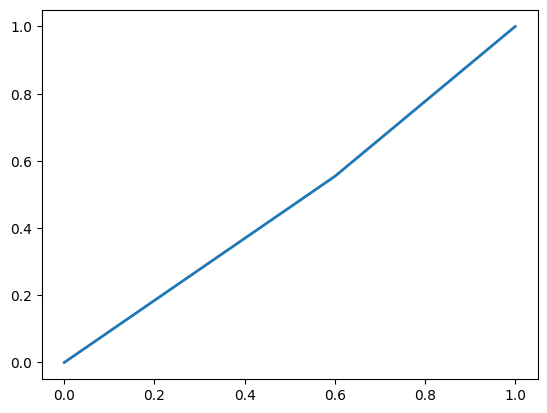

In [39]:
# Baseline

baseline = DummyClassifier(strategy='stratified', random_state=42)  # predicts according to class distribution
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, y_pred_baseline)
df_auc_all += [pd.DataFrame({'Model': ['Baseline'], 'AUC': [auc]})]
utils.logger.info(f"[VALIDATION] Baseline AUC: {auc}")

fpr, tpr, _ = roc_curve(y_val, y_pred_baseline)
plt.plot(fpr, tpr, lw=2, label='Baseline')
plt.show()

2025-09-14 01:20:29,960 [2204392441.py:16] [INFO] [VALIDATION] Logistic regression AUC: 0.594673791588437


Optimization terminated successfully.
         Current function value: 0.673495
         Iterations 4


,index,coef,p_value
3,is_home_team_True,0.320925,2.542654e-07
2,Opponent Season to Date Average Points,-0.158337,3.039951e-07
7,Fatigue Level_Fatigued Team,-0.300265,1.190998e-03
1,Season to Date Average Points,0.076038,1.294870e-02
6,Fatigue Level_Fatigued Opponent,0.223688,1.896949e-02
0,const,0.128333,2.009718e-02
4,Trap Game_True,0.047956,5.393725e-01
5,Season Bucket_Post-Lockout (2013-2019),-0.007453,9.023898e-01


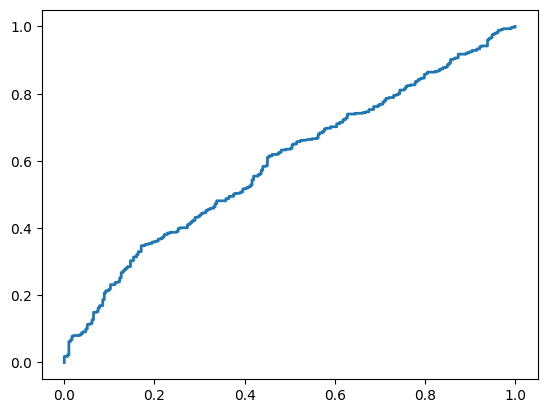

In [41]:
# Logistic Regression

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

df_coef_logistic = pd.DataFrame({
    'coef': result.params,
    'p_value': result.pvalues
}).reset_index(drop=False)

X_val_sm = sm.add_constant(X_val)
y_pred_logistic = result.predict(X_val_sm)
auc = roc_auc_score(y_val, y_pred_logistic)
df_auc_all += [pd.DataFrame({'Model': ['Logistic Regression'], 'AUC': [auc]})]
utils.logger.info(f"[VALIDATION] Logistic regression AUC: {auc}")

display(df_coef_logistic.sort_values('p_value'))
fpr, tpr, _ = roc_curve(y_val, y_pred_logistic)
plt.plot(fpr, tpr, lw=2)
plt.show()

In [23]:
regularized_models = {
    # need liblinear solver as we default doesn't support l1 loss
    'Ridge Regularized': LogisticRegressionCV(cv=10, penalty='l2', solver='liblinear', scoring='roc_auc', max_iter=1000),
    'Lasso Regularized': LogisticRegressionCV(cv=10, penalty='l1', solver='liblinear', scoring='roc_auc', max_iter=1000),
    'ElasticNet Regularized': LogisticRegressionCV(cv=10, penalty='elasticnet', solver='saga', l1_ratios=[0.5], scoring='roc_auc', max_iter=2000)
}

for name, model in regularized_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    df_auc_all += [pd.DataFrame({'Model': [name], 'AUC': [auc]})]
    utils.logger.info(f"[VALIDATION] {name} AUC: {auc}")

    df_coef = pd.DataFrame({'feature': X_train.columns, 
                            'coef': model.coef_[0]})
    display(df_coef.sort_values('coef', ascending=False))

2025-09-14 01:12:36,641 [840804682.py:14] [INFO] [VALIDATION] Ridge Regularized AUC: 0.5946281839810881


,feature,coef
2,is_home_team_True,0.319555
5,Fatigue Level_Fatigued Opponent,0.219958
0,Season to Date Average Points,0.075850
3,Trap Game_True,0.047554
4,Season Bucket_Post-Lockout (2013-2019),-0.006849
1,Opponent Season to Date Average Points,-0.157849
6,Fatigue Level_Fatigued Team,-0.294129


2025-09-14 01:12:36,985 [840804682.py:14] [INFO] [VALIDATION] Lasso Regularized AUC: 0.5944837598911499


,feature,coef
2,is_home_team_True,0.320836
5,Fatigue Level_Fatigued Opponent,0.205009
0,Season to Date Average Points,0.073730
3,Trap Game_True,0.034177
4,Season Bucket_Post-Lockout (2013-2019),0.000000
1,Opponent Season to Date Average Points,-0.155778
6,Fatigue Level_Fatigued Team,-0.277318


2025-09-14 01:12:37,485 [840804682.py:14] [INFO] [VALIDATION] ElasticNet Regularized AUC: 0.590531100587578


,feature,coef
2,is_home_team_True,0.291462
5,Fatigue Level_Fatigued Opponent,0.136650
0,Season to Date Average Points,0.066027
4,Season Bucket_Post-Lockout (2013-2019),0.000000
3,Trap Game_True,0.000000
1,Opponent Season to Date Average Points,-0.146299
6,Fatigue Level_Fatigued Team,-0.214436


In [24]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'random_state': 0,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_prob)
    return auc

In [25]:
# Random Forest
rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=50)
utils.logger.info(f"Best RF AUC: {rf_study.best_value}")
utils.logger.info(f"Best RF params: {rf_study.best_params}")

[I 2025-09-14 01:12:37,510] A new study created in memory with name: no-name-f9ea32d4-15ca-416f-9fd1-4707d6b3fbb1
[I 2025-09-14 01:12:38,290] Trial 0 finished with value: 0.5890982615900332 and parameters: {'n_estimators': 400, 'max_depth': 5}. Best is trial 0 with value: 0.5890982615900332.
[I 2025-09-14 01:12:39,461] Trial 1 finished with value: 0.59020804670219 and parameters: {'n_estimators': 543, 'max_depth': 6}. Best is trial 1 with value: 0.59020804670219.
[I 2025-09-14 01:12:41,940] Trial 2 finished with value: 0.5747280646411822 and parameters: {'n_estimators': 902, 'max_depth': 9}. Best is trial 1 with value: 0.59020804670219.
[I 2025-09-14 01:12:42,641] Trial 3 finished with value: 0.5913368349840754 and parameters: {'n_estimators': 311, 'max_depth': 6}. Best is trial 3 with value: 0.5913368349840754.
[I 2025-09-14 01:12:44,780] Trial 4 finished with value: 0.584134633656894 and parameters: {'n_estimators': 872, 'max_depth': 7}. Best is trial 3 with value: 0.5913368349840754

2025-09-14 01:21:21,973 [1479732512.py:12] [INFO] [VALIDATION] RF AUC: 0.5993789764132658


,feature,importance
2,is_home_team_True,0.277539
1,Opponent Season to Date Average Points,0.260934
0,Season to Date Average Points,0.182279
6,Fatigue Level_Fatigued Team,0.160652
5,Fatigue Level_Fatigued Opponent,0.091210
3,Trap Game_True,0.019696
4,Season Bucket_Post-Lockout (2013-2019),0.007690


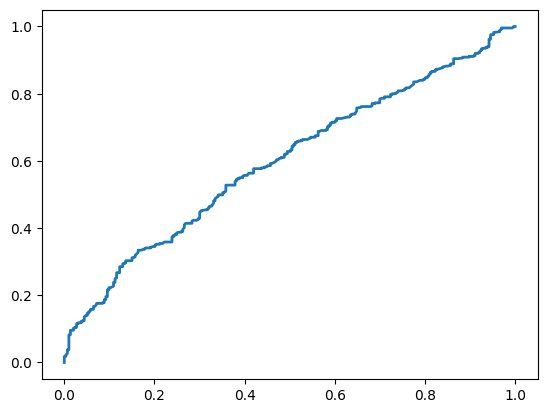

In [42]:
best_rf = RandomForestClassifier(**rf_study.best_params)
best_rf.fit(X_train, y_train)

df_importance = pd.DataFrame(
    {'feature': X_train.columns, 
     'importance': best_rf.feature_importances_,
    }).sort_values('importance', ascending=False)

y_pred_rf = best_rf.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred_rf)
df_auc_all += [pd.DataFrame({'Model': ['Random Forest'], 'AUC': [auc]})]
utils.logger.info(f"[VALIDATION] RF AUC: {auc}")

display(df_importance)

fpr, tpr, _ = roc_curve(y_val, y_pred_rf)
plt.plot(fpr, tpr, lw=2)
plt.show()

In [27]:
def gb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'random_state': 0,
    }
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_prob)
    return auc

In [28]:
# Gradient Boosting
gb_study = optuna.create_study(direction='maximize')
gb_study.optimize(gb_objective, n_trials=50)
utils.logger.info(f"Best GB AUC: {gb_study.best_value}")
utils.logger.info(f"Best GB params: {gb_study.best_params}")

[I 2025-09-14 01:13:09,882] A new study created in memory with name: no-name-4ed24913-6b3d-4793-9cac-5cc59d26cfa8
[I 2025-09-14 01:13:12,192] Trial 0 finished with value: 0.5651618689997491 and parameters: {'n_estimators': 767, 'max_depth': 3, 'learning_rate': 0.03105552696692268}. Best is trial 0 with value: 0.5651618689997491.
[I 2025-09-14 01:13:14,300] Trial 1 finished with value: 0.5789505689549017 and parameters: {'n_estimators': 713, 'max_depth': 3, 'learning_rate': 0.010268183174848748}. Best is trial 1 with value: 0.5789505689549017.
[I 2025-09-14 01:13:17,488] Trial 2 finished with value: 0.5322749834672423 and parameters: {'n_estimators': 649, 'max_depth': 5, 'learning_rate': 0.27911285356772597}. Best is trial 1 with value: 0.5789505689549017.
[I 2025-09-14 01:13:18,313] Trial 3 finished with value: 0.5159056530629309 and parameters: {'n_estimators': 163, 'max_depth': 5, 'learning_rate': 0.1740874777946194}. Best is trial 1 with value: 0.5789505689549017.
[I 2025-09-14 01:1

In [29]:
best_gb = GradientBoostingClassifier(**gb_study.best_params)
best_gb.fit(X_train, y_train)

auc = roc_auc_score(y_val, best_gb.predict_proba(X_val)[:,1])
df_auc_all += [pd.DataFrame({'Model': ['Gradient Boosted'], 'AUC': [auc]})]
utils.logger.info(f"[VALIDATION] GB AUC: {auc}")

df_importance = pd.DataFrame(
    {'feature': X_train.columns, 
     'importance': best_gb.feature_importances_,
    }).sort_values('importance', ascending=False)
df_importance

2025-09-14 01:14:15,899 [3720894218.py:6] [INFO] [VALIDATION] GB AUC: 0.5907097303830279


,feature,importance
1,Opponent Season to Date Average Points,0.334189
0,Season to Date Average Points,0.282185
2,is_home_team_True,0.249768
6,Fatigue Level_Fatigued Team,0.085693
5,Fatigue Level_Fatigued Opponent,0.045811
3,Trap Game_True,0.002354
4,Season Bucket_Post-Lockout (2013-2019),0.000000


In [30]:
df_auc_all = pd.concat(df_auc_all, axis=0).reset_index(drop=True).sort_values('AUC', ascending=False)
df_auc_all

,Model,AUC
5,Random Forest,0.597444
1,Logistic Regression,0.594674
2,Ridge Regularized,0.594628
3,Lasso Regularized,0.594484
6,Gradient Boosted,0.590710
4,ElasticNet Regularized,0.590531
0,Baseline,0.476942
